# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = 'alejandroldz2004@gmail.com'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    # Para indicar a MLflow donde debe guardar los datos del experimento
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    # Indica a MLflow donde guardar las runs del experimento
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/alejandroldz2004@gmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
# para hacer la division de los datos entre train y test
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
# Sirve para encadenar un conjunto de transformaciones y pasos de manera sencilla y automatica
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
#un random forest (un conjunto de arboles de decision) y un SGDC (stochastic gradient descent classifier)
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
#para hacer validacion cruzada, es decir, evaluar al modelo entrenando y validando con todos los datos, dividiendo el dataset en varias partes. Devuelve un array con las puntuaciones de cada fold
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
# principalmente recall para poder priorizar la detección de verdaderos positivos. Tambien la precisión para asegurarnos de que no estamos clasificando mal los negativos.
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
# carpeta data, donde encontramos el csv heart.csv. Basicamente el dataset que vamos a usar. Contiene datos de pacientes y el target
data = pd.read_csv('../data/raw/heart.csv')

# TODO: Muestra número de filas, columnas y variable objetivo.
print(data.shape)
print(data["target"])


(303, 14)
0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.
# Con esto podemos comprobar que el dataset esta bien formado y nos da una idea de como esta estructurado
print("🔍 Primeras 5 filas del dataset:\n")
data.head()

🔍 Primeras 5 filas del dataset:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
data.info()
# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
#categoricas: "sex", "cp", "fbs", "restecg", "exang", "slope"
#numericas: "age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal", "target"



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
# describe() nos da un resumen rápido de cada columna numérica: media, desviación estándar,
# valor mínimo, máximo y los percentiles. Es útil para detectar rangos y posibles valores atípicos.

data.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.
# La edad va de 29 a 77, trestbps de 94 a 200 y chol de 131 a 564. Las medias son de 54 en age, 131 en trestbps, 246 en chol y 150 en thalach. Las columnas age, trestbps, chol, thalach y oldpeak presentan algunos valores que podrían ser atípicos al comparar los extremos con sus percentiles. En trestbps, el 75% está por debajo de 140, mientras que el máximo es 200. En oldpeak, el 75% está por debajo de 1.6, pero el máximo llega a 6.2. En cambio, age y thalach muestran rangos más coherentes con sus percentiles, aunque sus valores máximos también están alejados del 75%.

,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización
---
- La edad media de los pacientes es de 54 años, con una desviación estandar de 9, lo que nos indica que la mayoria de edades es aproximadamente de 45 a 63 años
- La edad tiene un minimo de 29 y un maximo de 77 años, el trestbps entre 94 y 200, el chol entre 131 y 564, el thalach entre 71 y 202, el oldpeak entre 0 y 6.2, el ca entre 0 y 4, y el thal entre 0 y 3.
- Parece haber valores nulos, ya que algunas columnas tienen menos de 303 datos
- Todas las características requieren ser normalizadas, ya que vamos a usar modelos sensibles a la escala como SGDC.

In [0]:
# TODO: Analiza la distribución de la variable objetivo. 
target_counts = data.target.value_counts()
print(target_counts)


# TODO: Calcula proporciones por clase.
print(f"no enfermos: {target_counts[0]/len(data)*100}")
print(f"enfermos: {target_counts[1]/len(data)*100}")
# TODO: Decide si el dataset está balanceado y explica por qué importa.
# Sí está balanceado, hay un 45.5% de no enfermos y un 54% de enfermos. La diferencia es pequeña por lo que podemos decir que está balanceado. Es importante porque si están desbalanceados podemos tener muy pocos ejemplos de una clase y no obtener el resultado deseado


target
1    165
0    138
Name: count, dtype: int64
no enfermos: 45.54455445544555
enfermos: 54.45544554455446


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

<Axes: >

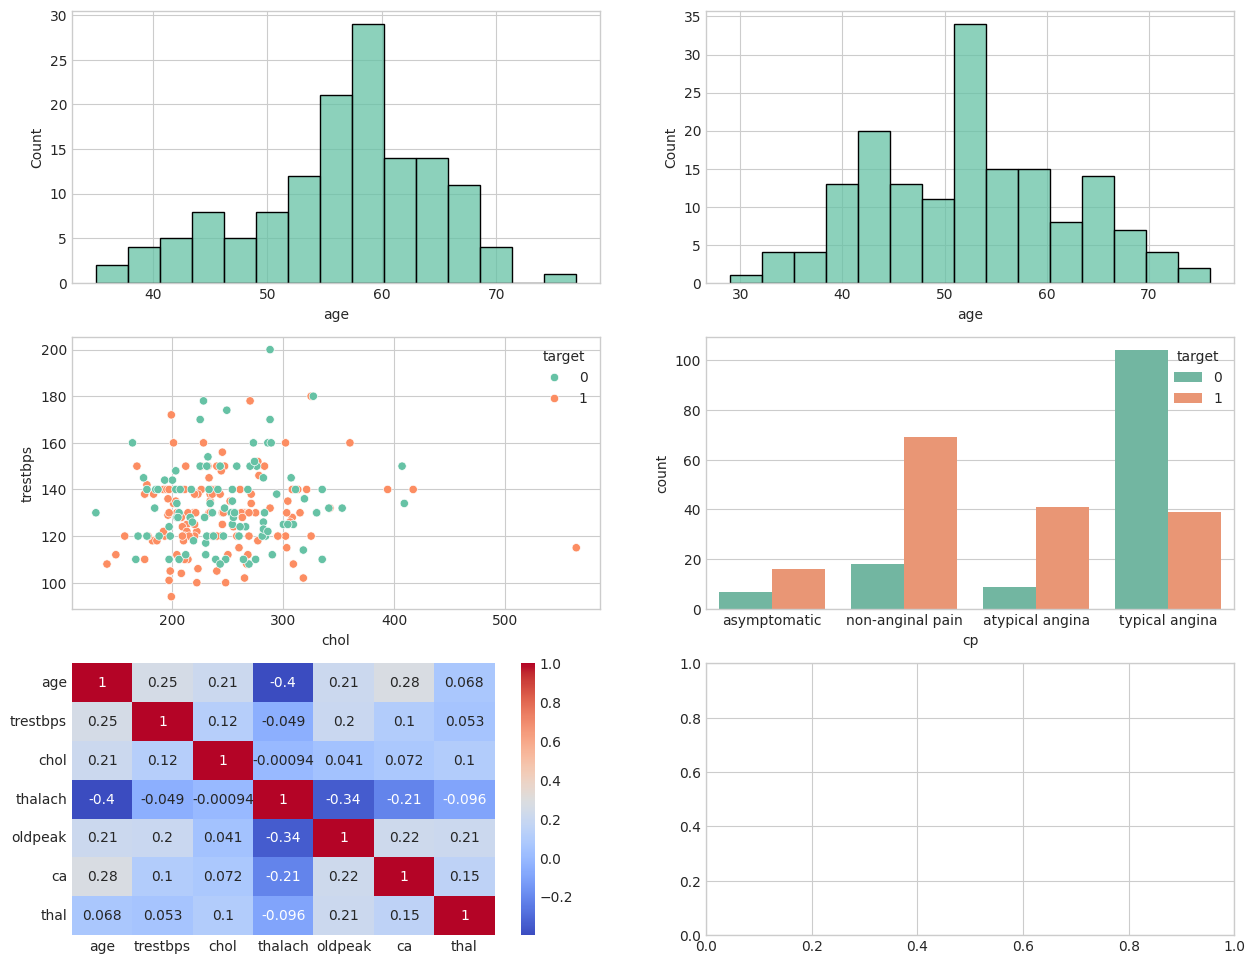

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

sns.histplot(data=data[data["target"] == 0], x="age", bins=15, ax=axes[0, 0])
sns.histplot(data=data[data["target"] == 1], x="age", bins=15, ax=axes[0, 1])

sns.scatterplot(data=data, x="chol", y="trestbps", hue="target", ax=axes[1, 0])

sns.countplot(data=data, x="cp", hue="target", ax=axes[1, 1])

numerical_columns = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]
corr_matrix = data[numerical_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[2,0])


# TODO: Escribe qué patrones observas en los gráficos.
# Se puede observar la relacion entre la edad y la enfermedad, la relacion entre el colesterol y la presion arterial, la relacion entre el tipo de dolor de pecho y la enfermedad (en donde se ve claramente que cuando es asintomático no suele haber enfermedad, mientras que si lo hay en caso contrario) y la relacion entre las caracteristicas de la matriz de correlacionen donde se observa que las caracteristicas que más afectan al target son el ca, thalach y oldpeak, mientras que el resto de características son casi irrelevantes, excepto la edad que tiene tambien algo de importancia

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

train_set, test_set = train_test_split(data, test_size=0.2, random_state=0)


# TODO: Comprueba el tamaño de cada conjunto.
print(len(train_set), len(test_set))


242 61


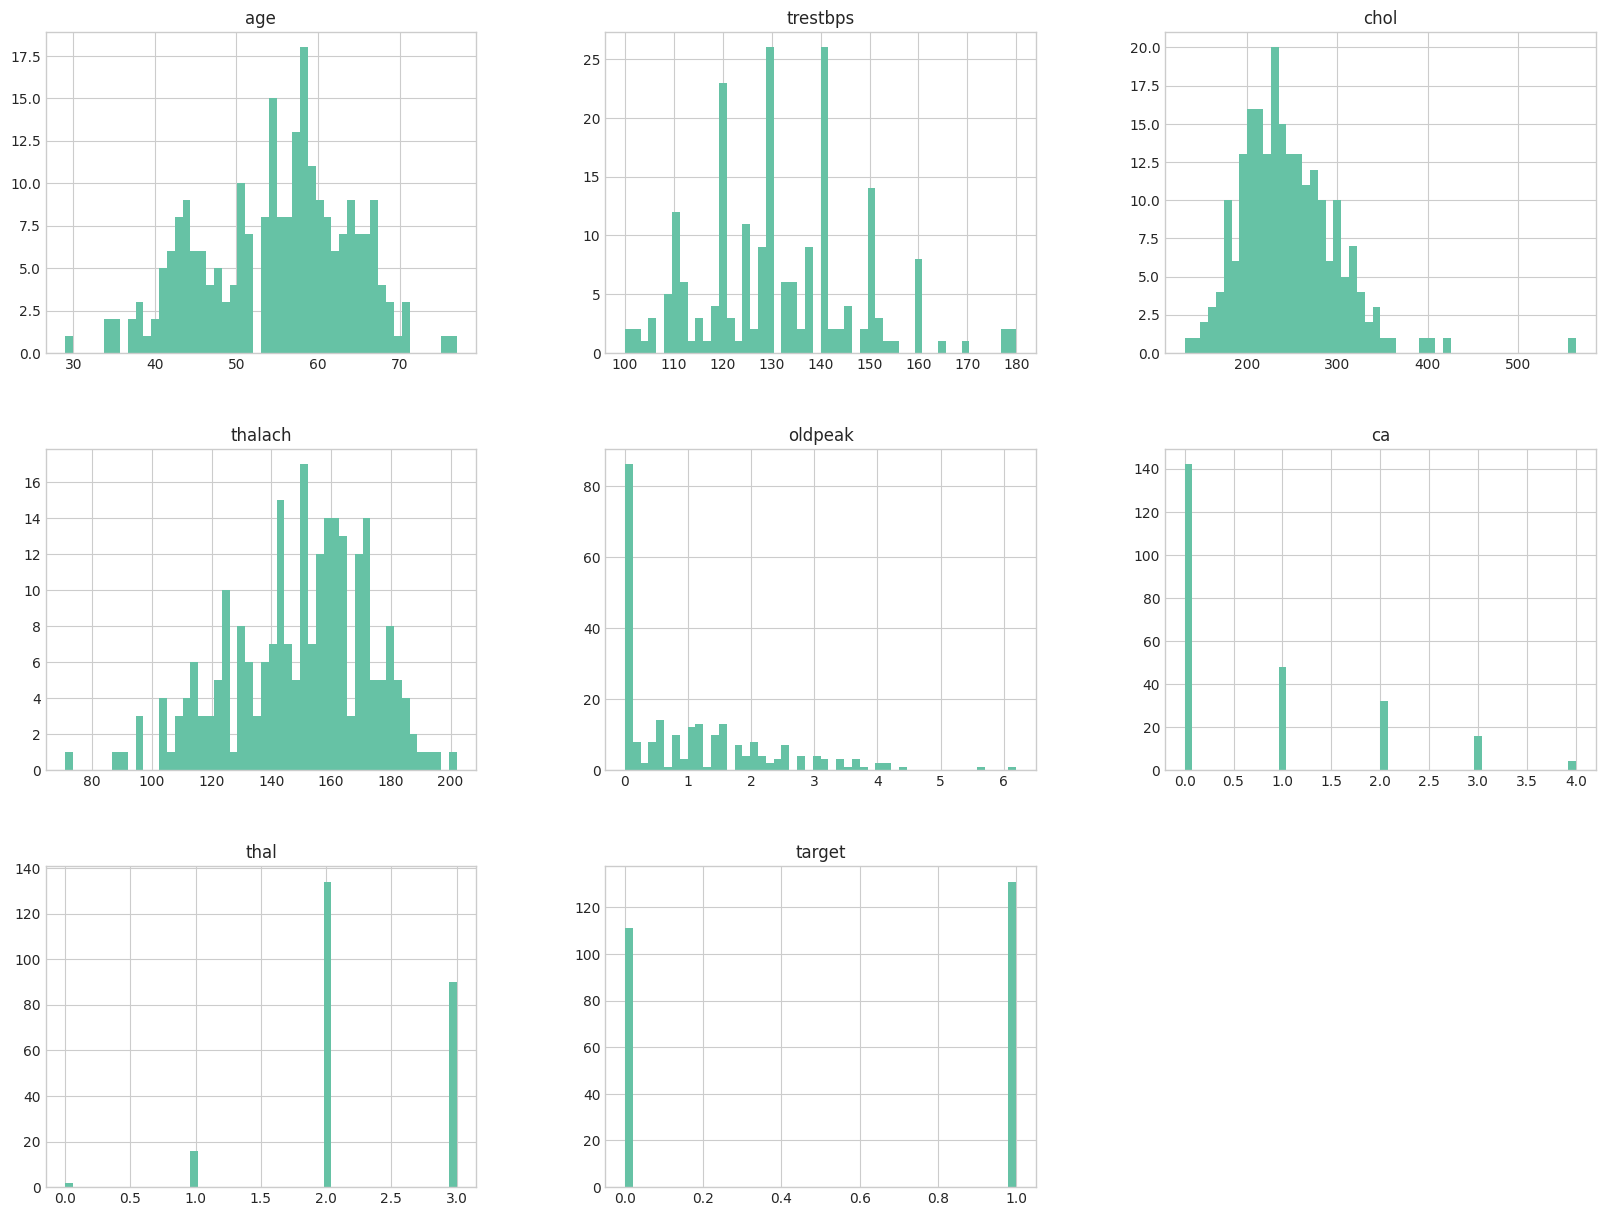

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
train_set.hist(bins=50, figsize=(20, 15))
plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.
#trestbps y oldpeak tienen distribuciones muy diferentes al resto, thalach y age y col (exceptuando los outliers de este ultimo) siguen distribuciones muy parecidas, mientras que el resto presentan muy pocos valores posibles, lo que nos impide comparar con el resto de caracteristicas en las mismas condiciones.


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**
Porque hay modelos sensibles a la escala, que en caso de no normalizar las características, provocaria que algunas con maginutes mayores tuvieran más peso en el modelo cuando en realidad no lo tienen.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**
Las escalaria en un rango de 0 a 1 según los valores de cada característica para que las comparaciones sean justas

**TODO: [Completa aquí] ¿Por qué esto ayuda a los modelos de Machine Learning?**
Hace que todo tenga la misma escala, por lo que no hay características con magnitudes diferentes a otras, y asi evitamos lo mencionado anteriormente

## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]
# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("std_scaler", StandardScaler())
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
full_pipeline = ColumnTransformer([
    ("pipe", num_pipeline, num_attr),
    ("onehot", OneHotEncoder(), cat_attr),
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
# Para que sean variables numéricas, ya que no todos los modelos pueden tratar con variables no numéricas.

## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
x_train = train_set.drop("target", axis=1) 
y_train = train_set["target"]

# TODO: Comprueba las dimensiones resultantes.
print(x_train.shape)
print(y_train.shape)

(242, 13)
(242,)


In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento. 

x_train_pr = full_pipeline.fit_transform(x_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# fit_transform "aprende" de los datos y aplica las transformaciones en base a esos datos, mientras que tranform solo aplica las transformaciones en base a lo que haya aprendido anteriormente. Es por eso que fit_transform se aplica al entrenamiento y transform se aplica al test. Así el test se escala y transforma en base a los datos de entrenamiento, evitando así introducir información del test en los datos de entrenamiento.
# TODO: Comprueba cómo cambia el número de columnas.
print(x_train_pr.shape)
print(x_train.shape)

2026/09/23 12:33:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o397.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

(242, 23)
(242, 13)


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**
- un algoritmo que tiene unos parametros que optimiza iterativamente para minimizar el error
Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(random_state=42)
#     TODO: Evalúa con cross_val_score.
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=3, scoring='accuracy')
#
#     TODO: Registra métricas de validación cruzada en MLflow.
    mlflow.log_metric("mean_scores", scores.mean())
    print(scores)
    print(scores.mean())
#     TODO: Interpreta el resultado obtenido.
# El modelo acierta el 80% de los casos de media. Según el fold usado, esto puede variar +-5%, lo que indica diferencias entre particiones. Aún asi el resultado es bueno


2026/09/23 12:33:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o441.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

[0.75308642 0.80246914 0.85      ]
0.8018518518518518


### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=3)

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
# Porque nos devuelve una lista con las predicciones de todo el dataset, pero asegurandonos de que no hay datos que ya se han usado en el entrenamiento. Con esto podemos visualizar como generaliza el modelo


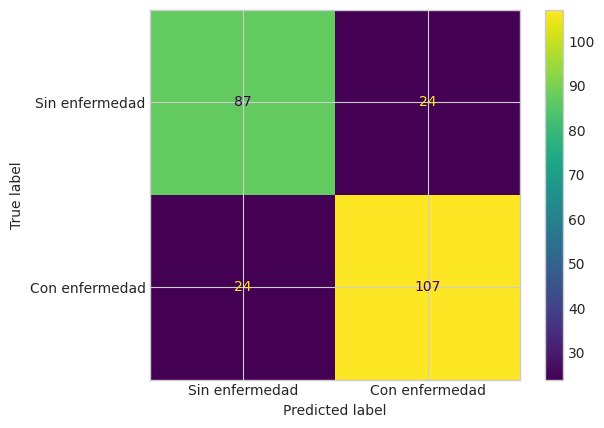

In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enfermedad', 'Con enfermedad'])
disp.plot()
plt.show()

# TODO: Interpreta TN, FP, FN y TP.
# TODO: ¿Qué tipo de error es más grave en medicina?
#Que aparezcan muchos falsos positivos, ya que las consecuencias pueden ser muy grandes. Es decir, positivos que no se detectan.


In [0]:
# TODO: Calcula métricas del modelo SGD.
precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

# TODO: Imprime e interpreta las métricas.
print("Precision: ", precision)
print("Recall: ", recall)
print("F1: ", f1)
print("Roc auc: ", roc_auc)

# TODO: ¿Qué métrica es más importante en medicina y por qué?
# el recall es la más importante, por que queremos reducir los falsos positivos, aunque debe tener un equilibrio con la precision, por ello tambien es importante analizar el f1

Precision:  0.816793893129771
Recall:  0.816793893129771
F1:  0.816793893129771
Roc auc:  0.8002888384567775


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**
- Es un modelo que combina muchos arboles de dicision para tomar una decision mediante una votacion. Funciona mejor porque suele evitar el sobreajuste que puede aparecer en un arbol de decisión 

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier(random_state=42)
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=3)
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
#
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.
#Random Forest es un modelo más complejo que SGD, por lo que es más probable que tenga mejores resultados. Algunos de los hiperparametros que podemos ajustar son: 
    # min_samples_leaf: el mínimo de muestras que debe haber en un nodo para que se pueda dividir
    # max_depth: profundidad máxima del árbol
    # n_estimators: número de árboles en el bosque
    # max_features: número máximo de características a considerar al buscar la mejor división
    # entre otros


2026/09/23 12:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o452.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

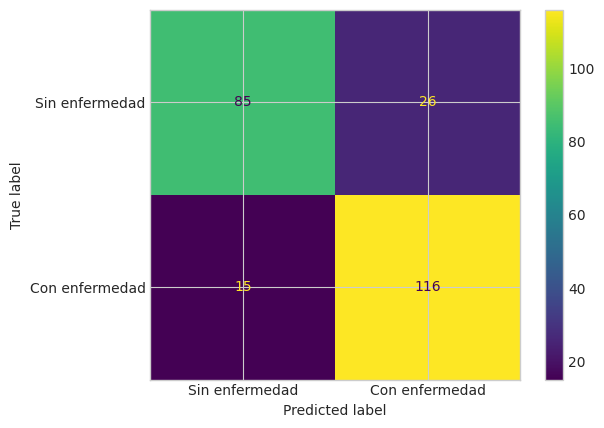

In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Sin enfermedad', 'Con enfermedad'])
disp_rf.plot()
plt.show()

# TODO: Compara los errores con los del modelo SGD.
# Los resultados mejoran. Se reducen los falsos postivos y los falsos negativos. Esto indica que este modelo logra aprender mejor las características que diferencian a las personas con enfermedad de las que no

In [0]:
# TODO: Calcula métricas de Random Forest.
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

# TODO: Crea una tabla comparativa SGD vs Random Forest.
print("Prec \t\t Rec \t\t F1 \t\t Roc \t\t Modelo")
print(f"{precision:.2f} \t\t {recall:.2f} \t\t {f1:.2f} \t\t {roc_auc:.2f} \t\t SGD")
print(f"{rf_precision:.2f} \t\t {rf_recall:.2f} \t\t {rf_f1:.2f} \t\t {rf_roc_auc:.2f} \t\t RF")
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.
#Claramente funciona mejor el RandomForest ya que tiene mejores resultados en todas las métricas, principalmente en el recall, que es la métrica importante para este caso

Prec 		 Rec 		 F1 		 Roc 		 Modelo
0.82 		 0.82 		 0.82 		 0.80 		 SGD
0.82 		 0.89 		 0.85 		 0.83 		 RF


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.
#Para hacer que el modelo tenga la mayor capacidad de generalización posible, al tener mas datos de entrenamiento, ya que tenemos el conjunto de test aparte donde evaluaremos el modelo

2026/09/23 12:33:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o463.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

RandomForestClassifier(random_state=42)

In [0]:
# TODO: Separa características y target del conjunto de prueba.
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

# TODO: Comprueba dimensiones.
print(x_test.shape)
print(y_test.shape)


(61, 13)
(61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.
#para aplicar las transformaciones en base a los datos de entrenamiento, que contiene mayor información y que son mas representativos, y para que el modelo "entienda" los datos de test y reciba el mismo formato que en el entrenamiento. Si usaramos fit_transform, estariamos, por ejemplo, escalando los datos de forma diferente al entrenamiento, con numeros diferentes, por lo que el modelo no funcionaria correctamente

2026/09/23 12:34:04 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o507.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

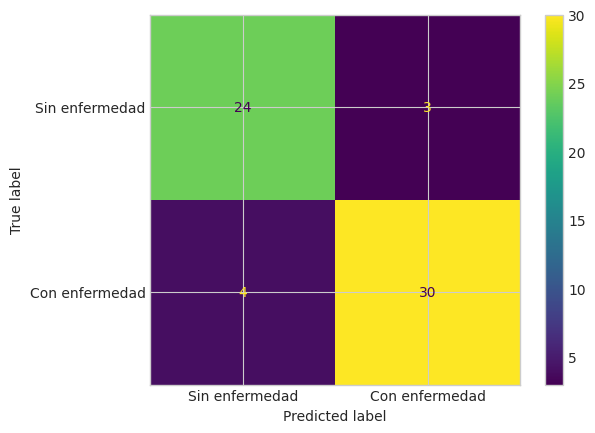

              precision    recall  f1-score   support

           0       0.86      0.89      0.87        27
           1       0.91      0.88      0.90        34

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

# TODO: Visualiza la matriz de confusión final.
cm_test = confusion_matrix(y_test, final_preds)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=['Sin enfermedad', 'Con enfermedad'])
disp_test.plot()
plt.show()
# TODO: Genera classification_report.
print(classification_report(y_test, final_preds))
# TODO: Interpreta si el modelo generaliza bien
# # Si, porque estamos ante el conjunto de test, que nunca ha visto, y tiene resultados muy buenos. Logra acertar casi todos los datos, tanto negativos como positivos. La metrica más importante, que es el recall, presenta un resultado muy positivo sin tener una precision baja


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión


### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - El RandomForest

2. **¿Por qué crees que funcionó mejor?**
   - Porque mantuvo un recall muy similar al SGD, pero mejoró bastante la precisión, y por tanto el F1 score

3. **¿El modelo es suficientemente bueno para uso médico?**
   - Ambos estan bien en este caso, aunque es mejor el RandomForest. 

4. **¿Qué métrica es más importante en este caso?**
   - El recall principalmente

5. **¿Qué mejorarías del modelo?**
   - la precisión la mejoraría un poco más, ya que el recall es bueno pero a costa de una precision menor, aunque aún así el rendimiento es muy bueno. Ajustando hiperparámetros se podría conseguir quizás

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - los falsos positivos son mas graves porque implican un mayor riesgo de la vida humana

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - No, ya que depende del contexto, y no siempre puede estar una IA funcionando correctamente

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - Para saber si la decisión del modelo tiene sentido o no y poder cuestionarla, contrastarla o confiar en ella

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


2026/09/23 14:14:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o669.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

{'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}
RandomForestClassifier(max_depth=7, min_samples_leaf=5, random_state=42)


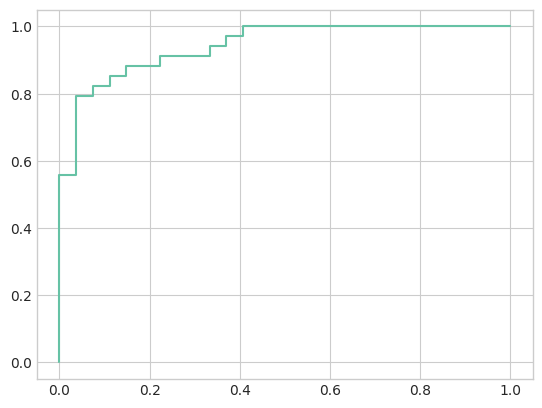

In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
from sklearn.model_selection import GridSearchCV
param_grid = {"max_depth": [3, 5, 7], "n_estimators": [10, 50, 100], "min_samples_leaf": [1, 3, 5]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="recall")
grid_search.fit(x_train_pr, y_train)
print(grid_search.best_params_)
print(grid_search.best_estimator_)
model = grid_search.best_estimator_

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
from sklearn.metrics import roc_curve, auc
y_proba = model.predict_proba(x_test_pr)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# TODO: visualiza la curva ROC.
plt.plot(fpr, tpr)
plt.show()





In [0]:
# TODO: identifica e interpreta las características más importantes.
feature_names = data.drop("target", axis=1).columns
feature_importance = model.feature_importances_
for f, i in zip(feature_names, feature_importance):
    print(f"{f}: {i}")

age: 0.06631518571689715
sex: 0.027727499576112303
cp: 0.03338733299519262
trestbps: 0.08912381448675225
chol: 0.10826590669429924
fbs: 0.161800241065878
restecg: 0.09930615130152248
thalach: 0.03919914703639171
exang: 0.032837236434817216
oldpeak: 0.002884150838597951
slope: 0.002824112544180371
ca: 0.027362403677913733
thal: 0.11998439438406752


In [0]:
# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

modelos = {
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression()
}
resultados = []
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=nombre):
        modelo.fit(x_train_pr, y_train)
        y_pred = modelo.predict(x_test_pr)

        recall = recall_score(y_test, y_pred)

        mlflow.log_metric("recall", recall)

        resultados.append((nombre, recall))

print(resultados)

2026/09/23 14:19:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o736.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

[('Gradient Boosting', 0.8529411764705882), ('SVM', 0.8823529411764706), ('Logistic Regression', 0.8823529411764706)]
